In [22]:
import json
from datetime import datetime
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [23]:
# Configuration
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

DATA_DIR = Path("/home/skada009/aro/spambase_10_40_50")
MODEL_PATH = DATA_DIR / "spambase_mlp.pth"
PREPROC_PATH = DATA_DIR / "preprocessing.npz"
DATA_PATH = DATA_DIR / "train_test_data.npz"

MAXITERS = 300
ALPHA = 0.1
SVD_RANK = 20
ATTACK_FRACTION_IN_ATTACK_SET = 0.5
ATTACK_CONFIGS = {"aggressive": 0.1, "stealthy": 50.0}
ATTACK_SUBSET_SEED = 42
K_RANKS = [1, 2, 3, 5, 10, 15, 20, 30, 40, 50, 57]
OUTPUT_DIR = Path("experiments/experiment2_reconstruction_outputs") / datetime.now().strftime("%Y%m%d_%H%M%S")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

Device: cuda


In [24]:
# Load model checkpoint
print("Loading model checkpoint...")
checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)

class SpambaseNet(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.layer = nn.Sequential(
            nn.Linear(input_size, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 2), nn.Softmax(dim=-1)
        )

    def forward(self, x):
        if x.dim() == 1:
            x = x.unsqueeze(0)
            return self.layer(x).squeeze(0)
        return self.layer(x)

model = SpambaseNet(57).to(DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f"✓ Model loaded | Train: {checkpoint.get('train_accuracy', 'N/A')}, Test: {checkpoint.get('test_accuracy', 'N/A')}")

Loading model checkpoint...
✓ Model loaded | Train: 0.9097826086956522, Test: 0.894393741851369


In [25]:
# Load data
data = np.load(DATA_DIR / 'train_test_data.npz')
X_train = data['X_train'].astype(np.float32)  # 1840-sample MLP train partition (not used for Vt)
n_svd_basis_rows = int(data['X_svd'].shape[0])
X_test = data['X_test'].astype(np.float32)
y_test = data['y_test']
n_test, n_features = X_test.shape

preproc = np.load(PREPROC_PATH)
weights = preproc['weights'].astype(np.float32)
bounds_min = preproc['bounds_min'].astype(np.float32)
bounds_max = preproc['bounds_max'].astype(np.float32)
bounds = [bounds_min, bounds_max]
print(f"✓ Bounds: [{bounds_min.min():.4f}, {bounds_max.max():.4f}]")

✓ Bounds: [0.0000, 1.0000]


In [26]:
def clip_to_bounds(x, low, high, device):
    low = torch.FloatTensor(low).to(device)
    high = torch.FloatTensor(high).to(device)
    return torch.max(torch.min(x, high), low)


def lowprofool_attack(x, model, weights, bounds, max_iters, alpha, lambda_param, device):
    x = x.to(device)
    v = torch.FloatTensor(np.array(weights)).to(device)
    r = torch.FloatTensor(1e-4 * np.ones(x.shape)).to(device)
    r.requires_grad = True

    with torch.no_grad():
        orig_pred = model(x).argmax().cpu().item()

    target_label = 1 - orig_pred
    target = torch.tensor([0.0, 1.0] if target_label == 1 else [1.0, 0.0]).to(device)
    bce_loss = nn.BCELoss()

    for _ in range(max_iters):
        if r.grad is not None:
            r.grad.zero_()
        output = model(x + r)
        loss_bce = bce_loss(output, target)
        loss_l2 = torch.sqrt(torch.sum((v * r) ** 2))
        loss = loss_bce + lambda_param * loss_l2
        loss.backward(retain_graph=True)
        with torch.no_grad():
            r_new = r - alpha * r.grad
        r = r_new.clone().detach().requires_grad_(True)

    x_adv = clip_to_bounds(x + r, bounds[0], bounds[1], device)
    with torch.no_grad():
        adv_pred = model(x_adv).argmax().cpu().item()

    return int(orig_pred), int(adv_pred), x_adv.detach().cpu().numpy()


In [27]:
def project_to_svd(x, Vh, singular_vals, rank=None):
    max_rank = len(singular_vals)
    effective_rank = max_rank if rank is None else int(np.clip(rank, 1, max_rank))
    inv_s = np.zeros_like(singular_vals, dtype=np.float32)
    inv_s[:effective_rank] = (1.0 / np.maximum(singular_vals[:effective_rank], 1e-12)).astype(np.float32)
    return (x @ Vh.T) * inv_s

def unproject_from_svd(z, Vh, singular_vals, rank=None):
    max_rank = len(singular_vals)
    effective_rank = max_rank if rank is None else int(np.clip(rank, 1, max_rank))
    s_masked = np.zeros_like(singular_vals, dtype=np.float32)
    s_masked[:effective_rank] = singular_vals[:effective_rank].astype(np.float32)
    return (z * s_masked) @ Vh

def error_stats(errors):
    if len(errors) == 0:
        return {
            "mean": float('nan'),
            "median": float('nan'),
            "std": float('nan'),
            "min": float('nan'),
            "max": float('nan'),
        }
    return {
        "mean": float(np.mean(errors)),
        "median": float(np.median(errors)),
        "std": float(np.std(errors)),
        "min": float(np.min(errors)),
        "max": float(np.max(errors)),
    }

In [28]:
X_attack = X_test[:X_test.shape[0] // 2]
X_clean = X_test[X_test.shape[0] // 2:]
print(f"Data shapes: X_test={X_test.shape}, X_attack={X_attack.shape}, X_clean={X_clean.shape}")

svd_basis = np.load(DATA_DIR / 'clean_svd_basis.npz')
Vt_clean = svd_basis['Vt_svd'].astype(np.float32)
S_clean = svd_basis['S_svd']
print(f'Clean basis shape: Vt_clean = {Vt_clean.shape} (SVD rows = {n_svd_basis_rows})')
print(f'Top-10 singular values: {S_clean[:10].round(2)}')
print(f'Cumulative energy at each k:')
cumvar = np.cumsum(S_clean**2) / np.sum(S_clean**2)
for k in K_RANKS:
    print(f'  k={k:>2d}: {cumvar[k-1]:.4f}')

# Attack all of first half, keep second half clean
print(f"Data split: Attack all of {X_attack.shape[0]} samples (first half), keep all of {X_clean.shape[0]} samples clean (second half)")


Data shapes: X_test=(2301, 57), X_attack=(1150, 57), X_clean=(1151, 57)
Clean basis shape: Vt_clean = (57, 57) (SVD rows = 460)
Top-10 singular values: [4.76 3.28 2.39 2.28 2.13 2.06 2.05 1.96 1.89 1.7 ]
Cumulative energy at each k:
  k= 1: 0.2283
  k= 2: 0.3370
  k= 3: 0.3946
  k= 5: 0.4927
  k=10: 0.6813
  k=15: 0.7888
  k=20: 0.8536
  k=30: 0.9440
  k=40: 0.9813
  k=50: 0.9980
  k=57: 1.0000
Data split: Attack all of 1150 samples (first half), keep all of 1151 samples clean (second half)


In [34]:
# Get original predictions for attack set
y_pred_orig = []
with torch.no_grad():
    for x in X_attack:
        pred = model(torch.FloatTensor(x).to(DEVICE)).argmax().cpu().item()
        y_pred_orig.append(pred)
y_pred_orig = np.array(y_pred_orig)
print(f"✓ Original predictions: Class 0: {np.sum(y_pred_orig==0)}, Class 1: {np.sum(y_pred_orig==1)}")

for attack_name, lambda_val in ATTACK_CONFIGS.items():
    print(f"\n{'='*60}")
    print(f"Running {attack_name} attack (lambda={lambda_val})")
    print(f"{'='*60}")

    X_attacked = X_attack.copy()
    y_pred = y_pred_orig.copy()
    perturbations = np.zeros_like(X_attack, dtype=np.float32)
    success = np.zeros(X_attack.shape[0], dtype=np.int64)

    # Attack ALL samples in X_attack
    for idx in range(X_attack.shape[0]):
        if (idx + 1) % 100 == 0 or idx < 5 or idx == X_attack.shape[0] - 1:
            print(f"  [{idx + 1}/{X_attack.shape[0]}]", end=" ", flush=True)

        x_orig = torch.tensor(X_attack[idx], device=DEVICE)
        pred_orig, pred_adv, x_adv_np = lowprofool_attack(
            x=x_orig,
            model=model,
            weights=weights,
            bounds=bounds,
            max_iters=MAXITERS,
            alpha=ALPHA,
            lambda_param=lambda_val,
            device=DEVICE,
        )

        X_attacked[idx] = x_adv_np.astype(np.float32)
        y_pred[idx] = int(pred_adv)
        perturbations[idx] = (x_adv_np - X_attack[idx]).astype(np.float32)
        success[idx] = int(pred_orig != pred_adv)

        if (idx + 1) % 100 == 0 or idx == X_attack.shape[0] - 1:
            print(f"success={bool(success[idx])}")

    X_attacked = X_attacked.astype(np.float32)
    y_pred = y_pred.astype(np.int64)

    attack_dir = OUTPUT_DIR / attack_name
    attack_dir.mkdir(parents=True, exist_ok=True)

    # Compute SVD on X_attack
    U_attack, S_attack, Vt_attack = np.linalg.svd(X_attack, full_matrices=False)
    np.save(attack_dir / "U_attack.npy", U_attack)
    np.save(attack_dir / "S_attack.npy", S_attack)
    np.save(attack_dir / "Vt_attack.npy", Vt_attack)
    print(f"✓ SVD of X_attack saved")

    # Compute reconstruction error using X_attack's own SVD basis
    recon_attack_basis = {}
    for k in K_RANKS:
        Z_attacked_attack = project_to_svd(X_attacked, Vt_attack, S_attack, rank=k)
        X_attacked_recon_attack = unproject_from_svd(Z_attacked_attack, Vt_attack, S_attack, rank=k)
        err_attacked_attack = np.linalg.norm(X_attacked_recon_attack - X_attacked, axis=1)
        recon_attack_basis[k] = error_stats(err_attacked_attack)

    print(f"✓ Reconstruction using X_attack's SVD basis computed")

    # Compute reconstruction error for multiple ranks
    recon_results = {}
    for k in K_RANKS:
        # Project both attacked and clean data onto SVD
        Z_attack_orig = project_to_svd(X_attack, Vt_clean, S_clean, rank=k)
        Z_attacked = project_to_svd(X_attacked, Vt_clean, S_clean, rank=k)
        Z_clean = project_to_svd(X_clean, Vt_clean, S_clean, rank=k)

        # Reconstruct from SVD space
        X_attack_orig_recon = unproject_from_svd(Z_attack_orig, Vt_clean, S_clean, rank=k)
        X_attacked_recon = unproject_from_svd(Z_attacked, Vt_clean, S_clean, rank=k)
        X_clean_recon = unproject_from_svd(Z_clean, Vt_clean, S_clean, rank=k)

        # Compute reconstruction errors
        err_attack_orig = np.linalg.norm(X_attack_orig_recon - X_attack, axis=1)
        err_attacked = np.linalg.norm(X_attacked_recon - X_attacked, axis=1)
        err_clean = np.linalg.norm(X_clean_recon - X_clean, axis=1)

        # Debug: print info for first rank
        if k == K_RANKS[0]:
            print(f"  Debug info (k={k}):")
            print(f"    err_attack_orig shape: {err_attack_orig.shape}")
            print(f"    err_attacked shape: {err_attacked.shape}")
            print(f"    err_clean shape: {err_clean.shape}")
            print(f"    err_attacked mean: {np.mean(err_attacked):.6f}")
            print(f"    err_clean mean: {np.mean(err_clean):.6f}")

        mean_err_attacked = float(np.mean(err_attacked))
        mean_err_clean = float(np.mean(err_clean))
        mean_diff = mean_err_attacked - mean_err_clean

        recon_results[k] = {
            "rank": k,
            "original_before_attack": error_stats(err_attack_orig),
            "attacked": error_stats(err_attacked),
            "clean": error_stats(err_clean),
            "mean_attacked": mean_err_attacked,
            "mean_clean": mean_err_clean,
            "mean_difference": mean_diff,
            "ratio_attacked_over_clean": float(mean_err_attacked / np.maximum(mean_err_clean, 1e-12)),
        }


    # Compute summary statistics
    perturb_norms = np.linalg.norm(perturbations, axis=1)
    success_rate = float(np.mean(success))

    summary = {
        "attack_type": attack_name,
        "lambda": float(lambda_val),
        "n_attacked": int(X_attack.shape[0]),
        "n_clean": int(X_clean.shape[0]),
        "success_rate": success_rate,
        "avg_perturbation": float(np.mean(perturb_norms)),
        "median_perturbation": float(np.median(perturb_norms)),
        "svd_basis_rows": int(n_svd_basis_rows),
        "reconstruction_error_by_rank": recon_results,
        "reconstruction_attack_basis": recon_attack_basis,
    }

    with (attack_dir / "summary.json").open("w") as f:
        json.dump(summary, f, indent=2)

    # Print results for all ranks
    print(f"\n  {attack_name} attack results by rank:")
    print(f"  {'k':>3s} | {'attacked_err':>12s} | {'clean_err':>12s} | {'diff':>12s} | {'ratio':>8s}")
    print(f"  {'-'*70}")
    for k in K_RANKS:
        if k in recon_results:
            res = recon_results[k]
            ratio = res['ratio_attacked_over_clean']
            ratio_str = f"{ratio:.4f}" if not np.isnan(ratio) else "nan"
            print(
                f"  {k:3d} | {res['mean_attacked']:12.6f} | {res['mean_clean']:12.6f} | "
                f"{res['mean_difference']:12.6f} | {ratio_str:>8s}"
            )

print(f"\n✓ Done. Output: {OUTPUT_DIR}")

✓ Original predictions: Class 0: 719, Class 1: 431

Running aggressive attack (lambda=0.1)
  [1/1150]   [2/1150]   [3/1150]   [4/1150]   [5/1150]   [100/1150] success=True
  [200/1150] success=True
  [300/1150] success=True
  [400/1150] success=True
  [500/1150] success=True
  [600/1150] success=True
  [700/1150] success=True
  [800/1150] success=True
  [900/1150] success=True
  [1000/1150] success=True
  [1100/1150] success=True
  [1150/1150] success=True
✓ SVD of X_attack saved
✓ Reconstruction using X_attack's SVD basis computed
  Debug info (k=1):
    err_attack_orig shape: (1150,)
    err_attacked shape: (1150,)
    err_clean shape: (1151,)
    err_attacked mean: 1.136329
    err_clean mean: 0.327701

  aggressive attack results by rank:
    k | attacked_err |    clean_err |         diff |    ratio
  ----------------------------------------------------------------------
    1 |     1.136329 |     0.327701 |     0.808628 |   3.4676
    2 |     1.108817 |     0.311645 |     0.797172

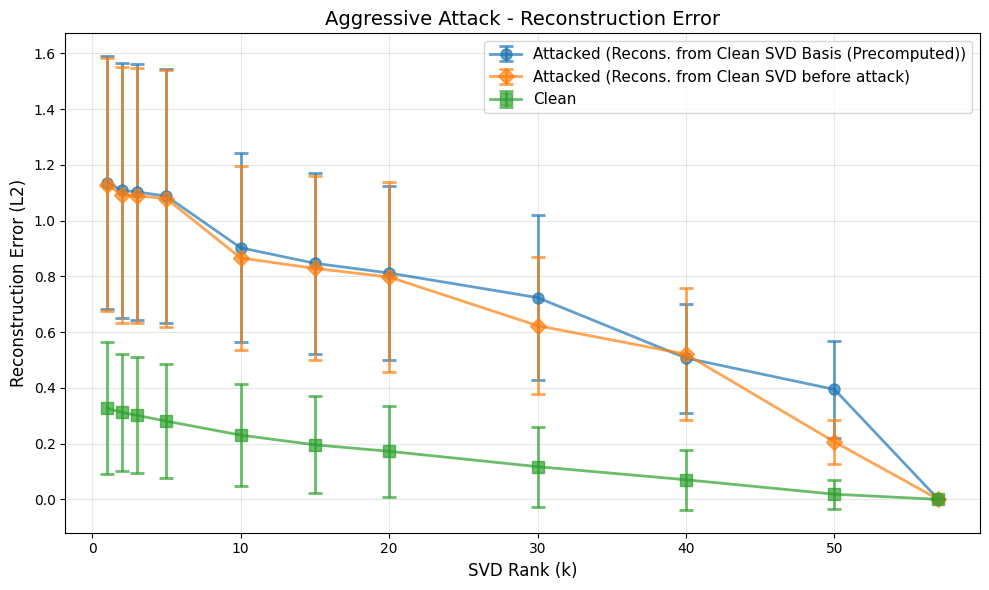

✓ Saved plot: experiments/experiment2_reconstruction_outputs/20260504_210406/aggressive/aggressive_reconstruction_error.png


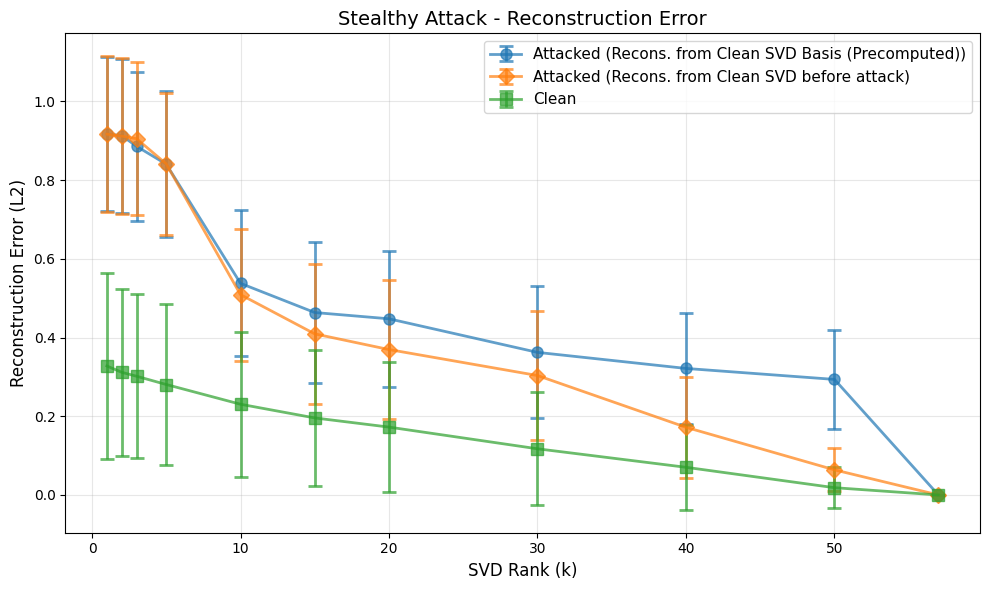

✓ Saved plot: experiments/experiment2_reconstruction_outputs/20260504_210406/stealthy/stealthy_reconstruction_error.png


In [38]:
# Create simple plot for each attack type
for attack_name in ATTACK_CONFIGS.keys():
    attack_dir = OUTPUT_DIR / attack_name
    summary_file = attack_dir / "summary.json"
    
    with open(summary_file) as f:
        summary = json.load(f)
    
    recon_by_rank = summary["reconstruction_error_by_rank"]
    recon_attack_basis = summary["reconstruction_attack_basis"]
    
    ranks = sorted([int(k) for k in recon_by_rank.keys()])
    original_means = [recon_by_rank[str(k)]["original_before_attack"]["mean"] for k in ranks]
    original_stds = [recon_by_rank[str(k)]["original_before_attack"]["std"] for k in ranks]
    attacked_means = [recon_by_rank[str(k)]["attacked"]["mean"] for k in ranks]
    attacked_stds = [recon_by_rank[str(k)]["attacked"]["std"] for k in ranks]
    clean_means = [recon_by_rank[str(k)]["clean"]["mean"] for k in ranks]
    clean_stds = [recon_by_rank[str(k)]["clean"]["std"] for k in ranks]

    # Add reconstruction using attack's own SVD basis
    attacked_attack_basis_means = [recon_attack_basis[str(k)]["mean"] for k in ranks]
    attacked_attack_basis_stds = [recon_attack_basis[str(k)]["std"] for k in ranks]
    
    plt.figure(figsize=(10, 6))
    # plt.errorbar(ranks, original_means, yerr=original_stds, marker='^', linewidth=2, markersize=8, 
    #              label='Original (Before Attack)', capsize=5, capthick=2, alpha=0.7)
    plt.errorbar(ranks, attacked_means, yerr=attacked_stds, marker='o', linewidth=2, markersize=8, 
                 label='Attacked (Recons. from Clean SVD Basis (Precomputed))', capsize=5, capthick=2, alpha=0.7)
    
    plt.errorbar(ranks, attacked_attack_basis_means, yerr=attacked_attack_basis_stds, marker='D', linewidth=2, markersize=8, 
             label='Attacked (Recons. from Clean SVD before attack)', capsize=5, capthick=2, alpha=0.7)
    plt.errorbar(ranks, clean_means, yerr=clean_stds, marker='s', linewidth=2, markersize=8, 
                 label='Clean', capsize=5, capthick=2, alpha=0.7)
    plt.xlabel('SVD Rank (k)', fontsize=12)
    plt.ylabel('Reconstruction Error (L2)', fontsize=12)
    plt.title(f"{attack_name.capitalize()} Attack - Reconstruction Error", fontsize=14)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    plot_file = attack_dir / f"{attack_name}_reconstruction_error.png"
    plt.savefig(plot_file, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved plot: {plot_file}")
    plt.close()
